In [29]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datetime(year=2021, month=7, day=4)

movies_df = pd.read_csv("clean_movies.csv")
genres_df = pd.read_csv("clean_genres.csv")
production_df = pd.read_csv("clean_production.csv")

In [2]:
movies_df

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,10/30/95,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,12/15/95,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,12/22/95,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,12/22/95,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,2/10/95,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45458,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45459,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,11/17/11,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45460,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,8/1/03,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45461,False,"{'id': 312977, 'name': 'Iron Sky Collection', ...",18000000,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",http://www.ironsky.net/,302349,tt3038708,en,Iron Sky: The Coming Race,"Twenty years after the events of Iron Sky, the...",...,3/1/18,0.0,0.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Post Production,NaN,Iron Sky: The Coming Race,False,0.0,0.0


In [30]:
#pulled in from the final project to play around with here
movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 10)]
movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]

In [31]:
#connection between month (release date) and profit / popularity

movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])
movies_df['month'] = movies_df['release_date'].dt.month

monthly_pop = movies_df.groupby('month')[['popularity']].mean()
print(monthly_pop.sort_values(by='popularity', ascending=True))

monthly_rev = movies_df.groupby('month')[['profit']].mean()
print(monthly_rev.sort_values(by='profit', ascending=True))

# Movies that are released in January tend to be ranked less favorably and are less profitable

/var/folders/km/h432qbx55ljb5h2m9n7_s65c0000gn/T/ipykernel_59432/3725669305.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])


       popularity
month            
1        8.161860
9        9.150551
8        9.332672
2        9.481768
12      10.099173
4       10.253416
3       10.606553
11      10.620812
10      10.878359
7       11.030157
5       11.223311
6       12.858538
             profit
month              
1      2.491995e+07
9      2.648658e+07
8      3.618124e+07
10     4.150934e+07
2      4.473337e+07
4      5.656634e+07
3      5.780860e+07
7      8.275270e+07
12     8.361846e+07
11     8.746040e+07
5      1.014035e+08
6      1.131307e+08


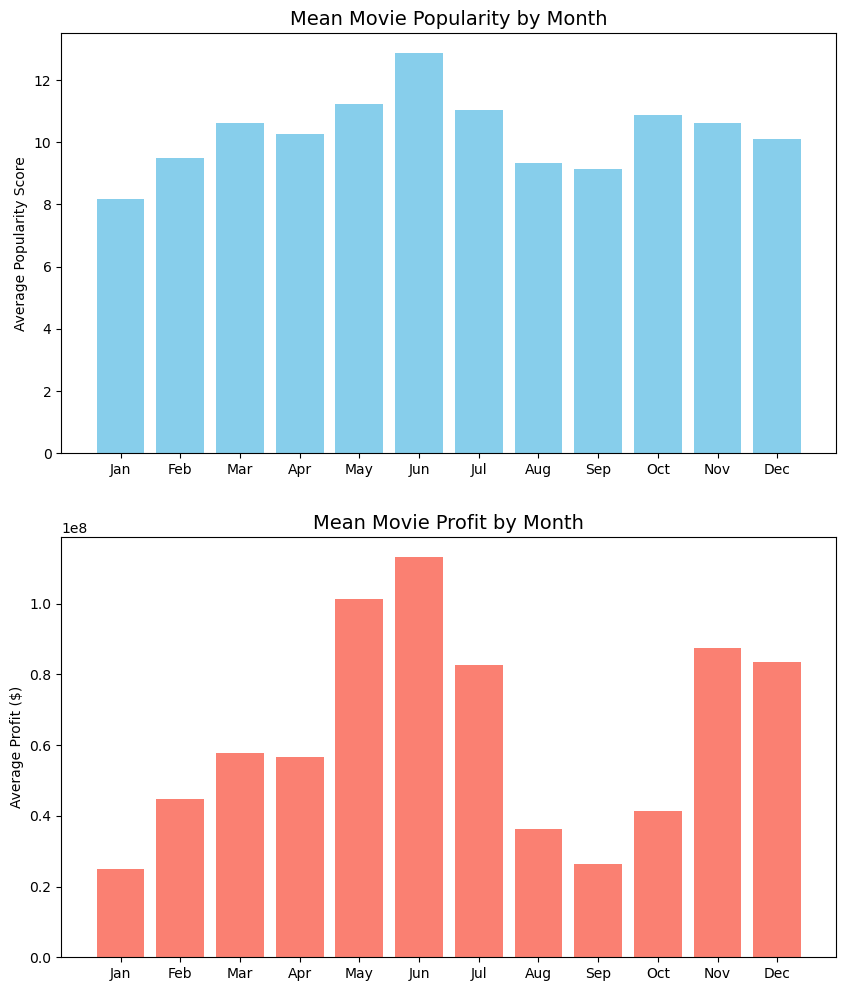

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.subplot(2, 1, 1)
plt.bar(monthly_pop.index, monthly_pop['popularity'], color='skyblue')
plt.title('Mean Movie Popularity by Month', fontsize=14)
plt.xticks(range(1, 13), month_labels)
plt.ylabel('Average Popularity Score')

plt.subplot(2, 1, 2)
plt.bar(monthly_rev.index, monthly_rev['profit'], color='salmon')
plt.title('Mean Movie Profit by Month', fontsize=14)
plt.xticks(range(1, 13), month_labels)
plt.ylabel('Average Profit ($)')

plt.show()


In [38]:
#worst movies and when they were released
least_popular= movies_df.sort_values('popularity').head(1000)
least_profitable = movies_df.sort_values('profit').head(1000)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

least_popular_by_month = overlap['month'].value_counts().sort_index()

print(least_popular_by_month)

month
1     15
2     19
3     19
4     22
5     18
6     20
7     12
8     21
9     37
10    34
11    29
12    24
Name: count, dtype: int64


In [37]:
overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,profit,month
20931,False,NaN,58000000,"[{'id': 35, 'name': 'Comedy'}]",http://www.theinternshipmovie.com/,116741,tt2234155,en,The Internship,Two recently laid-off men in their 40s try to ...,...,119.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Hiring them was a brilliant mistake.,The Internship,False,6.1,1691.0,-14000000.0,6
3121,False,NaN,36000000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,75531,tt0141399,de,Isn't She Great,An unsuccessful over-the-top actress becomes a...,...,95.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Talent Isn't Everything...,Isn't She Great,False,4.6,14.0,-32996704.0,1
3379,False,NaN,43000000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,54087,tt0104928,en,Mr. Saturday Night,"Buddy Young was the comic's comic, beloved by ...",...,119.0,[],Released,It's lonely at the middle.,Mr. Saturday Night,False,5.2,17.0,-29700000.0,9
8269,False,NaN,16000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10402, 'n...",NaN,43670,tt0339727,en,Stateside,The film follows a rebellious teenager on leav...,...,97.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Boy in a flack jacket meets girl in a straight...,Stateside,False,5.6,12.0,-15825682.0,5
10612,False,NaN,15000000,"[{'id': 28, 'name': 'Action'}, {'id': 27, 'nam...",NaN,19058,tt0247303,en,Down,After the elevators at a New York City skyscra...,...,111.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,YOUR NEXT STOP... IS HELL.,Down,False,4.1,18.0,-14836831.0,5
8893,False,NaN,25000000,"[{'id': 878, 'name': 'Science Fiction'}]",NaN,36677,tt0091981,en,Solarbabies,In a future in which most water has disappeare...,...,94.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Who will rule the future?,Solarbabies,False,5.1,12.0,-23420740.0,11
37604,False,NaN,17000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 53, '...",http://www.roarthemovie.com/,2989,tt0083001,en,Roar,Roar follows a family who are attacked by vari...,...,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,No animals were harmed in the making of this m...,Roar,False,5.6,19.0,-15000000.0,11
5203,False,NaN,18000000,"[{'id': 14, 'name': 'Fantasy'}, {'id': 35, 'na...",NaN,28117,tt0101701,en,Delirious,A soap opera writer gets hit on the head and w...,...,96.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A Comedy about a Soap Opera Writer Who's Typin...,Delirious,False,5.5,27.0,-12453173.0,8
31405,False,NaN,18000000,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",NaN,316654,tt2979920,hi,बॉम्बे वेलवेट,"An ordinary man, who goes against all odds to ...",...,151.0,"[{'iso_639_1': 'hi', 'name': 'हिन्दी'}]",Released,NaN,Bombay Velvet,False,5.4,17.0,-16500000.0,5
7162,False,NaN,39000000,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",NaN,8842,tt0312329,en,Against the Ropes,A fictional story inspired by North America's ...,...,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Against the Ropes,False,4.5,32.0,-32385720.0,2


In [ ]:
#has popularity risen, fallen or stayed static over time?

In [ ]:
#connection between genre and profit / popularity

In [ ]:
#connection between production company and profit / popularity